Här ska vi analysera och klustra 80-talshits från Spotify. Kaggle-datasetet innehåller massor av rolig data om hur låtarna låter (t.ex. hur dansanta de är, hur mycket energi de har, och om de låter glada eller ledsna).

In [6]:
%pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Exempel på låtar från de olika klustren:

--- Kluster 0 ---
['Crazy Little Thing Called Love', 'Against The Wind', 'Biggest Part Of Me']

--- Kluster 1 ---
['The Rose', 'Cars', 'Lady']

--- Kluster 2 ---
['Babe', 'Magic', 'We Don’t Talk Anymore']

--- Kluster 3 ---
['Desire', 'Real Love', 'Sara']


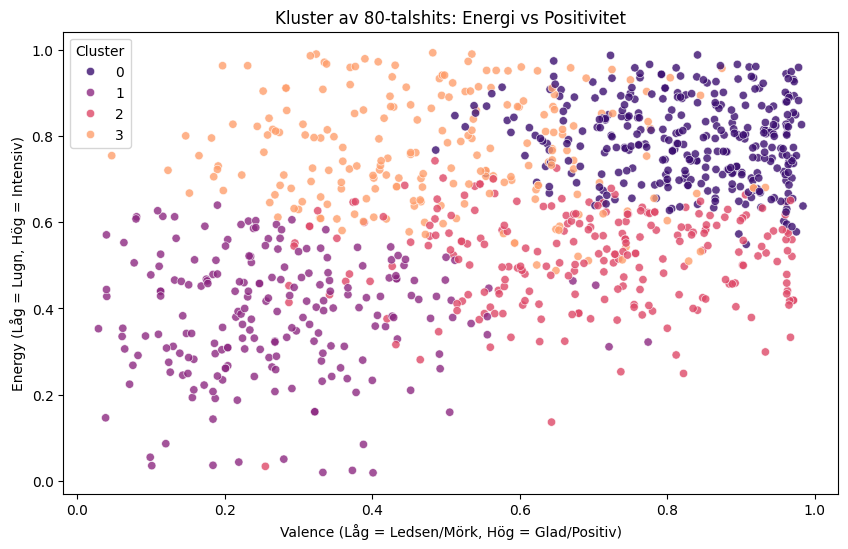

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Läs in datan
df = pd.read_csv("spotify.csv")

# Gör om alla kolumnnamn till små bokstäver och ta bort ev. osynliga mellanslag
# Detta löser problemet om kolumnerna heter 'Danceability' istället för 'danceability'
df.columns = df.columns.str.lower().str.strip()

# 2. Välj ut musikaliska egenskaper att klustra på
X = df[['danceability', 'energy', 'valence']]

# 3. Skalning av datan
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Träna K-means. Vi letar efter 4 olika "vibbar".
kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')
df['Cluster'] = kmeans.fit_predict(X_scaled)
df['Cluster'] = df['Cluster'].astype("category")

# 5. Visualisera klustren: Energi vs Positivitet (Valence)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='valence', y='energy', hue='Cluster', palette='magma', alpha=0.8)
plt.title('Kluster av 80-talshits: Energi vs Positivitet')
plt.xlabel('Valence (Låg = Ledsen/Mörk, Hög = Glad/Positiv)')
plt.ylabel('Energy (Låg = Lugn, Hög = Intensiv)')

# 6. Skriv ut ett par exempel-låtar från varje kluster
# Låtnamnet brukar kallas 'track', 'track_name' eller 'name' i dessa dataset
track_col = None
for col in ['track', 'track_name', 'name']:
    if col in df.columns:
        track_col = col
        break

if track_col:
    print("Exempel på låtar från de olika klustren:")
    for i in range(4):
        print(f"\n--- Kluster {i} ---")
        print(df[df['Cluster'] == i][track_col].head(3).tolist())
else:
    print("\nKunde inte hitta en kolumn för låtnamn, men klustringen lyckades!")

plt.show()